# M11 · Embeddings & Representation Learning — Hands-on, Step by Tiny Step

**Companion to lesson M11. Written for someone new to ML.**

An **embedding** turns any entity — a creator, a search query, an ad, a word — into a list of
numbers (a **vector**), placed in a space where **similar things sit close together**. That
lets you *search*, *cluster*, and *feed* entities into other models. The catch: "close" means
**"the training signal made these look similar,"** not "these are truly the same." This
notebook builds that intuition, then shows the two things you must be able to do:
**compare vectors correctly** and **check whether the space is any good.**

**What you'll do (every step has an explanation, logging, and a picture):**
- **Part A · What embeddings encode & similarity:** vectors as points, **dot product vs
  cosine**, why you **L2-normalize**, **ID vs text** embeddings, and the **checks before
  trusting neighbors** (norms, dot-vs-cosine, hubness).
- **Part B · Learning & evaluating:** **learn** an embedding with **negative sampling**,
  measure **alignment & uniformity**, then run the evaluation **checks** — **recall@k**,
  **slice checks** (the cold-start gap), and **probing**.

We use **scikit-learn** + **matplotlib** (no installs in Colab). Run each cell with
**Shift+Enter**.

## Step 1 · Setup

In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"axes.grid": True, "grid.alpha": .3, "figure.autolayout": True})
BLUE, GREEN, RED, PURPLE, GOLD, GRAY = "#4C72B0", "#55A868", "#C44E52", "#8172B3", "#CCB974", "#888"
print("ready")

ready


---
# Part A · What embeddings encode & similarity

## Step 2 · An embedding is just a point in space

Give each creator a short vector. Here we use **2 numbers** each so we can *draw* them. Nearby
points = "the training signal saw these as similar." Notice the fitness creators cluster
together and the finance ones cluster elsewhere — **that clustering is the whole value.**

dims usually aren't individually meaningful — read NEIGHBORHOODS, not single axes.


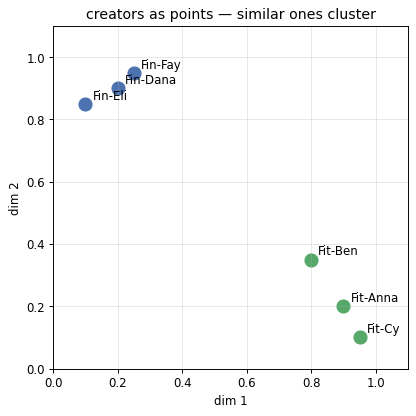

In [5]:
creators = {
    "Fit-Anna":   [0.9, 0.2], "Fit-Ben":  [0.8, 0.35], "Fit-Cy": [0.95, 0.1],
    "Fin-Dana":   [0.2, 0.9], "Fin-Eli":  [0.1, 0.85], "Fin-Fay": [0.25, 0.95],
}
plt.figure(figsize=(5,5))
for name,(x,y) in creators.items():
    c = GREEN if name.startswith("Fit") else BLUE
    plt.scatter(x,y,s=120,color=c); plt.annotate(name,(x,y),textcoords="offset points",xytext=(6,4))
plt.xlabel("dim 1"); plt.ylabel("dim 2"); plt.title("creators as points — similar ones cluster")
plt.xlim(0,1.1); plt.ylim(0,1.1); plt.show()
print("dims usually aren't individually meaningful — read NEIGHBORHOODS, not single axes.")

## Step 3 · The two ways to score similarity — dot product vs cosine

To rank items for a query you need a **similarity score**. The two you must know:
$$\text{dot}(q,x)=q^\top x \qquad \cos(q,x)=\frac{q^\top x}{\lVert q\rVert\,\lVert x\rVert}$$
- **Dot product** rewards **direction AND size (norm)**.
- **Cosine** divides out the norms → rewards **direction only** (the angle).

We use the lesson's exact example: query `q=[1,0]` and three items.

In [7]:
q = np.array([1.0, 0.0])
items = {"A (big norm, same dir)": np.array([10.0, 0.0]),
         "B (small norm, near dir)": np.array([0.8, 0.6]),
         "C (orthogonal)": np.array([0.0, 1.0])}
print(f"{'item':>26}{'dot':>8}{'cosine':>9}")
for name, x in items.items():
    dot = q @ x
    cos = dot / (np.linalg.norm(q)*np.linalg.norm(x))
    print(f"{name:>26}{dot:>8.2f}{cos:>9.2f}")
print("\ndot says A is 12.5x stronger than B (its norm is 10).")
print("cosine says A is only 0.2 ahead of B (norm ignored, pure angle).")

                      item     dot   cosine
    A (big norm, same dir)   10.00     1.00
  B (small norm, near dir)    0.80     0.80
            C (orthogonal)    0.00     0.00

dot says A is 12.5x stronger than B (its norm is 10).
cosine says A is only 0.2 ahead of B (norm ignored, pure angle).


## Step 4 · *See* the difference, and why you **normalize**

Plot the query and items as arrows. **Dot** cares how far the arrow reaches along the query;
**cosine** cares only about the angle. The norm often secretly encodes **popularity /
frequency** — so **dot-product retrieval can bury a niche-but-perfectly-aligned item under a
popular one.** **L2-normalizing** (scaling every vector to length 1) removes that, making dot
product *equal* cosine, so pure **direction** wins.

after normalizing, A and q point the same way (cosine 1.0), B is a 37-degree angle (0.8).
normalize when you DON'T want norm to act like a popularity prior.


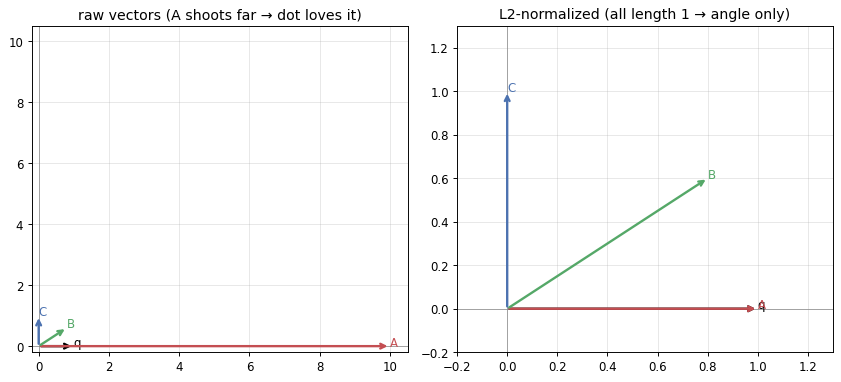

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4.6))
def arrows(a, title, normalize):
    a.axhline(0,color=GRAY,lw=.6); a.axvline(0,color=GRAY,lw=.6)
    vecs = {"q":(q,"k")} | {n:(x,c) for (n,x),c in zip(items.items(),[RED,GREEN,BLUE])}
    for name,(v,c) in vecs.items():
        vv = v/np.linalg.norm(v) if normalize else v
        a.annotate("",xy=vv,xytext=(0,0),arrowprops=dict(arrowstyle="->",color=c,lw=2))
        a.annotate(name.split()[0],vv,color=c)
    lim = 1.3 if normalize else 10.5
    a.set_xlim(-0.2,lim); a.set_ylim(-0.2,lim); a.set_title(title)
arrows(ax[0],"raw vectors (A shoots far → dot loves it)",False)
arrows(ax[1],"L2-normalized (all length 1 → angle only)",True)
plt.show()
print("after normalizing, A and q point the same way (cosine 1.0), B is a 37-degree angle (0.8).")
print("normalize when you DON'T want norm to act like a popularity prior.")

## Step 5 · ID embeddings vs text embeddings

Two ways to get an entity's vector:
- **ID embedding** — a **learned lookup** vector per entity. Great for entities with **lots of
  history** (their vector memorizes real behavior). **Fails for new entities** — a fresh ID
  has no history, so its vector is random.
- **Text embedding** — an **encoder** reads the entity's text (bio, title) → a vector. It
  **generalizes to unseen entities** (cold-start), but may **miss platform behavior** (who
  actually converts).

Below: a brand-new creator's **ID** vector is random noise, but its **text** vector still
lands near the right topic.

In [11]:
rng = np.random.default_rng(0)
d = 12
topic = rng.normal(0, 1, d); topic /= np.linalg.norm(topic)    # the 'cybersecurity' direction

established_id = topic + rng.normal(0, 0.05, d)   # learned ID vector: near the topic (rich history)
new_id        = rng.normal(0, 1, d)               # NEW creator's ID vector: random (no history!)
new_text      = topic + rng.normal(0, 0.15, d)    # text encoder: still near the topic from the bio

def cos(a, b): return a @ b / (np.linalg.norm(a) * np.linalg.norm(b))
print("cosine similarity to the 'cybersecurity' topic direction:")
print(f"  established creator, ID vector : {cos(established_id, topic):+.2f}  (history -> aligned)")
print(f"  NEW creator, ID vector         : {cos(new_id,  topic):+.2f}  (no history -> ~0, random!)")
print(f"  NEW creator, TEXT vector       : {cos(new_text, topic):+.2f}  (bio -> still aligned)")
print("\n-> production often BLENDS: text for cold-start, ID where history is rich.")

cosine similarity to the 'cybersecurity' topic direction:
  established creator, ID vector : +0.99  (history -> aligned)
  NEW creator, ID vector         : -0.48  (no history -> ~0, random!)
  NEW creator, TEXT vector       : +0.91  (bio -> still aligned)

-> production often BLENDS: text for cold-start, ID where history is rich.


## Step 6 · CHECK #1 — before you trust the neighbors

Never trust an embedding's neighbor list blindly. Three quick diagnostics from the lesson:
1. **Norms** — are a few high-norm vectors dominating?
2. **dot vs cosine neighbors** — do the top results *change* when you normalize? (if yes, norm
   is driving retrieval)
3. **Hubness** — is one vector the nearest neighbor of *many* unrelated queries?

CHECK norms:  min 2.14  median 3.88  max 19.47
  -> item 0 norm = 19.5 is a big outlier (a popularity hub?)

CHECK dot vs cosine neighbors for one query:
  top-5 by DOT   : [198, 272, 73, 307, 80] 
  top-5 by COSINE: [309, 272, 123, 109, 198] (norm removed -> different list)
CHECK hubness: biggest hub is the NN of 5 others (watch for these).


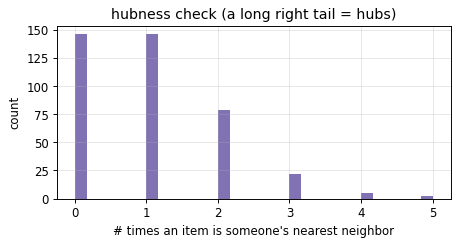

In [13]:
rng = np.random.default_rng(1)
E = rng.normal(0, 1, (400, 16))
E[0] *= 8   # plant one artificially popular "hub" with a huge norm

norms = np.linalg.norm(E, axis=1)
print("CHECK norms:  min %.2f  median %.2f  max %.2f" % (norms.min(), np.median(norms), norms.max()))
print("  -> item 0 norm = %.1f is a big outlier (a popularity hub?)\n" % norms[0])

q = rng.normal(0, 1, 16)
dot_top = np.argsort(-(E @ q))[:5]
En = E / norms[:, None]
cos_top = np.argsort(-(En @ (q/np.linalg.norm(q))))[:5]
print("CHECK dot vs cosine neighbors for one query:")
print("  top-5 by DOT   :", dot_top.tolist(), "(item 0 sneaks in via norm)" if 0 in dot_top else "")
print("  top-5 by COSINE:", cos_top.tolist(), "(norm removed -> different list)")

# hubness: how often is each item SOMEONE's nearest neighbor
S = En @ En.T; np.fill_diagonal(S, -1e9)
nn = np.argmax(S, axis=1); counts = np.bincount(nn, minlength=len(E))
plt.figure(figsize=(5.5,3)); plt.hist(counts, bins=30, color=PURPLE)
plt.xlabel("# times an item is someone's nearest neighbor"); plt.ylabel("count")
plt.title("hubness check (a long right tail = hubs)"); plt.show()
print("CHECK hubness: biggest hub is the NN of", counts.max(), "others (watch for these).")

---
# Part B · Learning & evaluating embeddings

## Step 7 · Learn an embedding with negative sampling

Now we *train* vectors instead of hand-placing them. Setup: **advertiser briefs** and
**creators**, each in a **vertical** (topic), and creators have a **tenure** (established vs
new). Positives = brief↔creator pairs that "matched" (established creators get more matches —
richer history). We learn brief and creator vectors so a **positive scores higher than a
random negative** (BPR / matrix factorization — the same negative-sampling idea as M10).

1000 briefs, 1400 creators, 3985 training positives
  epoch  0: avg BPR loss 0.6938
  epoch  8: avg BPR loss 0.2973
  epoch 16: avg BPR loss 0.1002
  epoch 24: avg BPR loss 0.0491
  epoch 32: avg BPR loss 0.0331


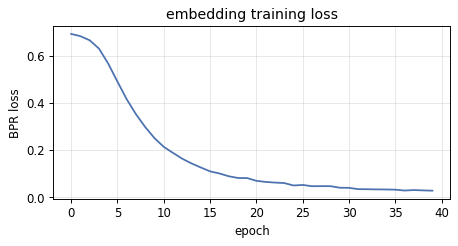

In [16]:
rng = np.random.default_rng(0)
dim, V = 16, 6
n_brief, n_creator = 1000, 1400

centers = rng.normal(0, 1, (V, dim))                 # a center per vertical (so topics cluster)
brief_v   = rng.integers(0, V, n_brief)
creator_v = rng.integers(0, V, n_creator)
Bf = centers[brief_v]   + rng.normal(0, 0.6, (n_brief, dim))     # TRUE latent taste (hidden)
Cf = centers[creator_v] + rng.normal(0, 0.6, (n_creator, dim))
established = rng.random(n_creator) < 0.7             # 70% established, 30% new
aff = Bf @ Cf.T

# build positive (brief, creator) pairs; established & common verticals get more interactions
train, test = {}, {}
for b in range(n_brief):
    w = np.exp(aff[b] - aff[b].max())
    w *= np.where(established, 4.0, 1.0)              # established -> more matches (rich history)
    w *= np.where(creator_v == 5, 0.25, 1.0)         # vertical 5 is RARE (few interactions)
    w /= w.sum()
    cs = list(rng.choice(n_creator, rng.integers(3, 8), replace=False, p=w))
    if len(cs) >= 2: test[b] = cs[-1]; train[b] = cs[:-1]   # hold out 1 positive per brief
    else: train[b] = cs
train_pairs = [(b, c) for b, cs in train.items() for c in cs]
print(f"{n_brief} briefs, {n_creator} creators, {len(train_pairs)} training positives")

# train with BPR: push positive above a random negative
Be = rng.normal(0, .1, (n_brief, dim)); Ce = rng.normal(0, .1, (n_creator, dim))
lr, reg = 0.1, 1e-5; losses = []
for epoch in range(40):
    rng.shuffle(train_pairs); tot = 0.0
    for b, c in train_pairs:
        neg = rng.integers(0, n_creator)
        diff = Be[b] @ Ce[c] - Be[b] @ Ce[neg]
        g = 1/(1 + np.exp(diff))                     # gradient weight = sigmoid(-diff)
        Be[b]  += lr * (g*(Ce[c]-Ce[neg]) - reg*Be[b])
        Ce[c]  += lr * (g*Be[b] - reg*Ce[c])
        Ce[neg]+= lr * (-g*Be[b] - reg*Ce[neg])
        tot += -np.log(1/(1+np.exp(-diff)))
    losses.append(tot/len(train_pairs))
    if epoch % 8 == 0: print(f"  epoch {epoch:>2}: avg BPR loss {losses[-1]:.4f}")
plt.figure(figsize=(5.5,3)); plt.plot(losses, color=BLUE)
plt.xlabel("epoch"); plt.ylabel("BPR loss"); plt.title("embedding training loss"); plt.show()

## Step 8 · CHECK #2 — alignment & uniformity

A good space needs **two** things:
- **Alignment** — positive pairs are **close**: `E‖f(x)−f(y)‖²` (lower = better).
- **Uniformity** — vectors **spread out**, not collapsed into one blob:
  `log E e^{−2‖x−y‖²}` (lower = more spread).

The trap: a **collapsed** space (everything ≈ the same point) has *great* alignment but
*terrible* uniformity — every neighbor list is the same, so retrieval can't discriminate. We
compare our trained space to a deliberately collapsed one.

In [18]:
def unit(X): return X / np.linalg.norm(X, axis=1, keepdims=True)   # these metrics live on the unit sphere
def alignment(x, y): return float(np.mean(np.sum((x - y)**2, axis=1)))
def uniformity(X, m=3000):
    i = rng.integers(0, len(X), m); j = rng.integers(0, len(X), m)
    return float(np.log(np.mean(np.exp(-2*np.sum((X[i]-X[j])**2, axis=1)))))

Bn, Cn = unit(Be), unit(Ce)                          # L2-normalize the learned vectors
bs = np.array(list(test.keys())); cs = np.array([test[b] for b in bs])
Xpos, Ypos = Bn[bs], Cn[cs]                          # held-out positive pairs (brief vs matched creator)

# a COLLAPSED space: every creator points in almost the SAME direction
v = rng.normal(0, 1, dim)
collapsed = unit(np.tile(v, (n_creator, 1)) + rng.normal(0, 0.05, (n_creator, dim)))
Xc = collapsed[cs]; Yc = unit(collapsed[cs] + rng.normal(0, 0.05, (len(cs), dim)))

print(f"{'space':>12}{'alignment':>12}{'uniformity':>12}")
print(f"{'trained':>12}{alignment(Xpos,Ypos):>12.3f}{uniformity(Cn):>12.2f}")
print(f"{'collapsed':>12}{alignment(Xc,Yc):>12.4f}{uniformity(collapsed):>12.2f}")
print("\ncollapsed has TINY alignment (looks great!) but uniformity ~0 (all jammed) -> useless.")
print("trained keeps positives close AND spreads everything else -> retrieval can discriminate.")

       space   alignment  uniformity
     trained       1.058       -3.17
   collapsed      0.0370       -0.01

collapsed has TINY alignment (looks great!) but uniformity ~0 (all jammed) -> useless.
trained keeps positives close AND spreads everything else -> retrieval can discriminate.


## Step 9 · CHECK #3 — retrieval recall@k (the first real metric)

The closest-to-production check: for each held-out positive, rank **all** creators by
similarity and ask **"is the true match in the top k?"** Averaged over briefs, that's
**recall@k**. Compare to a random baseline.

In [20]:
def recall_at_k(mask=None, k=20):
    hits = tot = 0
    for b, ti in test.items():
        if mask is not None and not mask(ti): continue
        s = Be[b] @ Ce.T
        for c in train[b]: s[c] = -1e9               # exclude training positives
        if ti in np.argpartition(-s, k)[:k]: hits += 1
        tot += 1
    return hits / max(tot, 1), tot

overall, n = recall_at_k()
print(f"recall@20 overall: {overall:.2f}  (over {n} briefs)")
print(f"random baseline  : {20/n_creator:.3f}   -> the model is far above random")

recall@20 overall: 0.50  (over 1000 briefs)
random baseline  : 0.014   -> the model is far above random


## Step 10 · CHECK #4 — SLICE checks (where cold-start hides)

**One overall number lies.** Break recall down by slice. Watch the **cold-start gap**:
established creators (rich history) retrieve well; **new** creators (little history) retrieve
poorly; a **rare vertical** is also weak. This is the single most important embedding check —
the fix isn't "bigger vectors," it's better text features / a cold-start blend / hard
negatives for rare verticals.

  recall@20             overall: 0.50
  recall@20         established: 0.53
  recall@20    new (cold-start): 0.23
  recall@20       rare vertical: 0.45
established >> new: the ID embedding memorized history the new creators don't have yet.


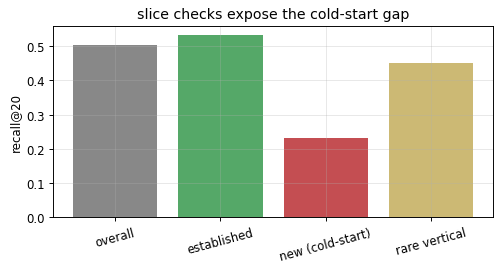

In [22]:
overall, _  = recall_at_k()
est, _      = recall_at_k(mask=lambda c: established[c])
new, _      = recall_at_k(mask=lambda c: not established[c])
rare, _     = recall_at_k(mask=lambda c: creator_v[c] == 5)
rows = [("overall", overall), ("established", est), ("new (cold-start)", new), ("rare vertical", rare)]
for name, r in rows: print(f"  recall@20  {name:>18}: {r:.2f}")

plt.figure(figsize=(6,3.3))
names = [r[0] for r in rows]; vals = [r[1] for r in rows]
plt.bar(names, vals, color=[GRAY, GREEN, RED, GOLD]); plt.ylabel("recall@20")
plt.title("slice checks expose the cold-start gap"); plt.xticks(rotation=15); plt.show()
print("established >> new: the ID embedding memorized history the new creators don't have yet.")

## Step 11 · CHECK #5 — probing (does the space encode what we think?)

Freeze the learned vectors and train a **tiny classifier** to predict a known label (here the
**vertical**) from them. High accuracy = the space really encodes topic structure. (Also a
bias audit: if a probe recovers a *protected* attribute you didn't intend, that's a red flag.)

probe: predict vertical from frozen creator vectors -> 0.49 accuracy
random guessing would be 1/6 = 0.17  -> the space clearly encodes vertical


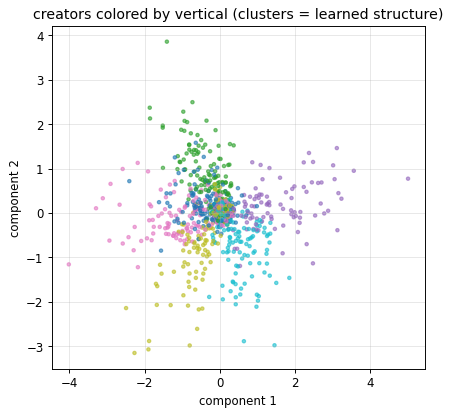

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
acc = cross_val_score(LogisticRegression(max_iter=1000), Ce, creator_v, cv=3).mean()
print(f"probe: predict vertical from frozen creator vectors -> {acc:.2f} accuracy")
print(f"random guessing would be 1/{V} = {1/V:.2f}  -> the space clearly encodes vertical")
# visualize: project to 2D and color by vertical
from numpy.linalg import svd
U, S, Vt = svd(Ce - Ce.mean(0), full_matrices=False)
proj = (Ce - Ce.mean(0)) @ Vt[:2].T
plt.figure(figsize=(5.2,5))
plt.scatter(proj[:,0], proj[:,1], c=creator_v, cmap="tab10", s=8, alpha=.6)
plt.xlabel("component 1"); plt.ylabel("component 2")
plt.title("creators colored by vertical (clusters = learned structure)"); plt.show()

---
## Recap — the M11 toolkit + the checklist

**What embeddings encode (Part A).** A vector's **neighborhood** reflects the **training
signal**, not universal truth. Compare vectors with **dot product** (direction *and* norm —
norm often acts like popularity) or **cosine** (direction only, after **L2-normalizing**).
**ID** embeddings memorize history (great for established entities, random for new ones);
**text** embeddings generalize to cold-start but miss platform behavior — so **blend** them.

**Learning & evaluating (Part B).** You learn vectors by pushing **positives above sampled
negatives** (matrix factorization / BPR). A healthy space has **alignment** (positives close)
**and uniformity** (everything spread) — collapse kills retrieval.

**The checks — never skip these:**
1. **Norms & hubness** — are a few high-norm vectors dominating / is one item everyone's neighbor?
2. **dot vs cosine neighbors** — do results change when you normalize? (then norm drives retrieval)
3. **Alignment & uniformity** — positives close *without* the space collapsing.
4. **recall@k** — of held-out positives, how many land in the top k?
5. **Slice checks** — new vs established, rare verticals, languages: **this is where cold-start hides.**
6. **Probing** — can a light classifier recover expected labels (and not leak protected ones)?
7. **Qualitative neighbors** — do the top neighbors actually make sense for the *product task*?

**Where this connects:** M11's vectors and negative sampling build on M10 (implicit labels,
logQ) and feed **M12 two-tower retrieval** — the system that searches these embeddings at
scale. Cold-start (M9) reappears as the ID-embedding weakness the slice checks expose.